# 02 — Cashflow Forecast: Adaptacion de rolling_mean al dominio de Tesoreria

**Basado en:** `cwc-workshops/agent-decomposition/.claude/skills/forecasting/rolling_mean.py`  
**Autor:** Gabriel Untiveros | **Fecha:** 2026-05-25

---

## Que construimos aqui

Dos scripts ejecutables que el agente usara via tool call:

| Script | Proposito | Equivalente en workshop |
|---|---|---|
| `rolling_mean_cashflow.py` | Forecast para UNA cuenta bancaria | `rolling_mean.py` |
| `batch_dias_de_caja.py` | Dias de caja de TODAS las cuentas rankeadas | `batch_days_of_cover.py` |

Mas el `SKILL.md` que le dice al agente **cuando usar cada script**.

## Tabla de equivalencias workshop -> tesoreria

| Workshop (inventario) | Este proyecto (tesoreria) |
|---|---|
| `sku` | `cuenta_id` |
| `units_sold` | `saldo_cierre` |
| `forecast_qty` (unidades) | `forecast_saldo` (soles/USD) |
| `days_of_cover` | `dias_de_caja` |
| `reorder_point` | `saldo_minimo_operativo` |
| `avg_daily_sales` | `flujo_neto_promedio_dia` |

In [1]:
import csv, json, sys
import pandas as pd
import numpy as np
from pathlib import Path

DATA_PATH   = Path('../data/movimientos_diarios.csv')
SKILLS_PATH = Path('../.claude/skills/forecast-cashflow')
SKILLS_PATH.mkdir(parents=True, exist_ok=True)

# Verificar que el CSV existe
assert DATA_PATH.exists(), f'Falta el CSV. Ejecuta primero NB 01.'
df = pd.read_csv(DATA_PATH)
print(f'CSV cargado: {len(df)} filas | Cuentas: {df["cuenta_id"].unique().tolist()}')

CSV cargado: 270 filas | Cuentas: ['CUENTA-001', 'CUENTA-002', 'CUENTA-003']


---
## El marco de decision: Path A vs Path B

Este patron viene directamente del `forecasting/SKILL.md` del workshop.
El agente elige el camino mas barato que da un resultado confiable:

```
PATH A — Calcular directamente (code execution)
Usar cuando:
  - horizonte <= 14 dias
  - cuenta sin pagos criticos programados
  - historial >= 14 dias
Costo: ~1 bash call, ~50 tokens

PATH B — Delegar a subagente
Usar cuando:
  - hay pagos programados criticos esta semana
  - la cuenta es 'critica' (ej: planilla)
  - horizonte > 14 dias
Costo: subagente propio, ~800+ tokens
```

> **Regla del workshop:** Usar un subagente cuando no necesitas uno
> desperdicia turns. Saltar el subagente cuando lo necesitas da un numero malo.

---
## Script 1: `rolling_mean_cashflow.py`

Forecast para UNA cuenta. Adapta `rolling_mean.py` del workshop con un campo nuevo: `dias_de_caja`.

**Diferencia clave con el workshop:**  
En inventario el forecast es *cuantas unidades vender*.  
En tesoreria el forecast es *cuanto saldo habra Y cuantos dias aguanta la empresa*.

In [2]:
# ── Definir el script como string para escribirlo a disco ──────────────
SCRIPT_ROLLING_MEAN = '''
#!/usr/bin/env python3
# Adaptado de: cwc-workshops/agent-decomposition/.claude/skills/forecasting/rolling_mean.py
# Cambios: sku->cuenta_id, units_sold->saldo_cierre, agrega dias_de_caja
"""
Forecast de saldo de caja — rolling mean 14 dias.

Uso:    python rolling_mean_cashflow.py CUENTA-001 14
Output: JSON con {cuenta_id, forecast_saldo, dias_de_caja, confidence, method, flags}
"""
import csv, json, sys
from pathlib import Path

DATA = Path(__file__).parent.parent.parent.parent / "data" / "movimientos_diarios.csv"
cuenta_id = sys.argv[1]
horizon   = int(sys.argv[2]) if len(sys.argv) > 2 else 14

# Cargar historial de saldos para esa cuenta
rows = [r for r in csv.DictReader(open(DATA)) if r["cuenta_id"] == cuenta_id]
if not rows:
    print(json.dumps({"error": f"Cuenta {cuenta_id} no encontrada"}))
    sys.exit(1)

moneda  = rows[0]["moneda"]
saldos  = [float(r["saldo_cierre"]) for r in rows]
ingresos = [float(r["ingresos_dia"]) for r in rows]
egresos  = [float(r["egresos_dia"]) for r in rows]

# Rolling mean 14 dias (o todo el historial si hay menos)
recent_saldos  = saldos[-14:] if len(saldos) >= 14 else saldos
recent_flujo   = [i - e for i, e in zip(ingresos[-14:], egresos[-14:])]

mean_saldo     = sum(recent_saldos) / max(len(recent_saldos), 1)
mean_flujo_dia = sum(recent_flujo) / max(len(recent_flujo), 1)

# Dias de caja: cuantos dias aguanta al ritmo actual de egresos
# (solo tiene sentido si el flujo neto es negativo)
saldo_actual = saldos[-1]
if mean_flujo_dia < 0:
    dias_de_caja = round(saldo_actual / abs(mean_flujo_dia), 1)
else:
    dias_de_caja = 999  # flujo positivo: sin limite en ventana actual

# Forecast: proyectar el saldo al horizonte dado
forecast_saldo = round(saldo_actual + mean_flujo_dia * horizon, 2)

tiene_14d = len(saldos) >= 14
print(json.dumps({
    "cuenta_id":      cuenta_id,
    "moneda":          moneda,
    "saldo_actual":    round(saldo_actual, 2),
    "forecast_saldo":  forecast_saldo,
    "dias_de_caja":    dias_de_caja,
    "flujo_neto_dia":  round(mean_flujo_dia, 2),
    "horizon_dias":    horizon,
    "confidence":      0.85 if tiene_14d else 0.60,
    "method":          "rolling_mean_14d",
    "flags":           [] if tiene_14d else ["historial_insuficiente"],
}))
'''

# Guardar el script a disco
script_path = SKILLS_PATH / 'rolling_mean_cashflow.py'
script_path.write_text(SCRIPT_ROLLING_MEAN.strip(), encoding='utf-8')
print(f'Script guardado: {script_path}')

Script guardado: ..\.claude\skills\forecast-cashflow\rolling_mean_cashflow.py


---
## Probar: forecast individual para cada cuenta

In [3]:
import subprocess

cuentas = ['CUENTA-001', 'CUENTA-002', 'CUENTA-003']
resultados = {}

for cuenta in cuentas:
    result = subprocess.run(
        [sys.executable, str(script_path), cuenta, '14'],
        capture_output=True, text=True
    )
    if result.returncode == 0:
        data = json.loads(result.stdout)
        resultados[cuenta] = data
        moneda = data['moneda']
        print(f'{cuenta} ({moneda})')
        print(f'  Saldo actual:    {moneda} {data["saldo_actual"]:>12,.2f}')
        print(f'  Forecast 14d:    {moneda} {data["forecast_saldo"]:>12,.2f}')
        print(f'  Dias de caja:    {data["dias_de_caja"]:>6} dias')
        print(f'  Flujo neto/dia:  {moneda} {data["flujo_neto_dia"]:>12,.2f}')
        print(f'  Confidence:      {data["confidence"]} | Flags: {data["flags"]}')
        print()
    else:
        print(f'ERROR {cuenta}: {result.stderr}')

CUENTA-001 (PEN)
  Saldo actual:    PEN   356,608.41
  Forecast 14d:    PEN   384,173.11
  Dias de caja:       999 dias
  Flujo neto/dia:  PEN     1,968.91
  Confidence:      0.85 | Flags: []

CUENTA-002 (PEN)
  Saldo actual:    PEN   224,330.79
  Forecast 14d:    PEN   242,378.90
  Dias de caja:       999 dias
  Flujo neto/dia:  PEN     1,289.15
  Confidence:      0.85 | Flags: []

CUENTA-003 (USD)
  Saldo actual:    USD   118,639.42
  Forecast 14d:    USD   121,264.03
  Dias de caja:       999 dias
  Flujo neto/dia:  USD       187.47
  Confidence:      0.85 | Flags: []



---
## Script 2: `batch_dias_de_caja.py`

El anti-patron que evitamos:
```
MALO:  for cuenta in cuentas: tool_call(get_forecast, cuenta)  # N calls
BUENO: python batch_dias_de_caja.py  # 1 call, JSON con todas
```

Del workshop: `batch_days_of_cover.py` reemplaza 100+ `get_stock_level` calls.  
Nuestro batch hace lo mismo para todas las cuentas bancarias.

Retorna las cuentas **rankeadas por urgencia** (menor `dias_de_caja` primero).

In [4]:
# Saldos minimos operativos por cuenta (en la vida real: config por cliente)
SALDOS_MINIMOS = {
    'CUENTA-001': 50_000,   # PEN — operativa
    'CUENTA-002': 10_000,   # PEN — planilla (fondeo cubre el minimo)
    'CUENTA-003': 5_000,    # USD — importaciones
}

SCRIPT_BATCH = f'''
#!/usr/bin/env python3
# Adaptado de: cwc-workshops/agent-decomposition/.claude/skills/forecasting/batch_days_of_cover.py
"""
Dias de caja para TODAS las cuentas, rankeadas por urgencia.

Uso:    python batch_dias_de_caja.py [top_n]
Output: JSON array ordenado por dias_de_caja ascendente
"""
import csv, json, sys
from pathlib import Path
from collections import defaultdict

DATA = Path(__file__).parent.parent.parent.parent / "data" / "movimientos_diarios.csv"
top_n = int(sys.argv[1]) if len(sys.argv) > 1 else 20

# Saldos minimos operativos por cuenta (configurar por cliente)
SALDO_MINIMO = {json.dumps(SALDOS_MINIMOS)}

# Agrupar historial por cuenta
historial = defaultdict(list)
for r in csv.DictReader(open(DATA)):
    historial[r["cuenta_id"]].append({{
        "fecha":        r["fecha"],
        "saldo_cierre": float(r["saldo_cierre"]),
        "ingresos_dia": float(r["ingresos_dia"]),
        "egresos_dia":  float(r["egresos_dia"]),
        "moneda":        r["moneda"],
    }})

rows = []
for cuenta_id, registros in historial.items():
    saldos   = [r["saldo_cierre"] for r in registros]
    ingresos = [r["ingresos_dia"]  for r in registros]
    egresos  = [r["egresos_dia"]   for r in registros]
    moneda   = registros[0]["moneda"]

    recent_flujo = [i - e for i, e in zip(ingresos[-14:], egresos[-14:])]
    mean_flujo   = sum(recent_flujo) / max(len(recent_flujo), 1)
    saldo_actual = saldos[-1]
    saldo_min    = SALDO_MINIMO.get(cuenta_id, 0)

    if mean_flujo < 0:
        dias_de_caja = round(saldo_actual / abs(mean_flujo), 1)
    else:
        dias_de_caja = 999

    rows.append({{
        "cuenta_id":         cuenta_id,
        "moneda":             moneda,
        "saldo_actual":       round(saldo_actual, 2),
        "saldo_minimo":       saldo_min,
        "dias_de_caja":       dias_de_caja,
        "flujo_neto_dia":     round(mean_flujo, 2),
        "bajo_minimo":        saldo_actual < saldo_min,
        "requiere_atencion":  dias_de_caja < 14 or saldo_actual < saldo_min,
        "confidence":         0.85 if len(saldos) >= 14 else 0.60,
    }})

rows.sort(key=lambda r: r["dias_de_caja"])
print(json.dumps(rows[:top_n], indent=2))
'''

batch_path = SKILLS_PATH / 'batch_dias_de_caja.py'
batch_path.write_text(SCRIPT_BATCH.strip(), encoding='utf-8')
print(f'Script guardado: {batch_path}')

Script guardado: ..\.claude\skills\forecast-cashflow\batch_dias_de_caja.py


---
## Probar: batch de todas las cuentas

In [5]:
result_batch = subprocess.run(
    [sys.executable, str(batch_path)],
    capture_output=True, text=True
)

if result_batch.returncode == 0:
    batch_data = json.loads(result_batch.stdout)
    print('Cuentas rankeadas por urgencia (menor dias_de_caja primero):')
    print()
    for row in batch_data:
        alerta = 'ALERTA' if row['requiere_atencion'] else 'OK'
        bajo   = ' [BAJO MINIMO]' if row['bajo_minimo'] else ''
        print(f"[{alerta}]{bajo}")
        print(f"  {row['cuenta_id']} ({row['moneda']})")
        print(f"  Saldo: {row['moneda']} {row['saldo_actual']:>12,.2f} | Minimo: {row['saldo_minimo']:>10,.0f}")
        print(f"  Dias de caja: {row['dias_de_caja']} | Flujo/dia: {row['flujo_neto_dia']:,.2f}")
        print()
else:
    print('ERROR:', result_batch.stderr)

Cuentas rankeadas por urgencia (menor dias_de_caja primero):

[OK]
  CUENTA-001 (PEN)
  Saldo: PEN   356,608.41 | Minimo:     50,000
  Dias de caja: 999 | Flujo/dia: 1,968.91

[OK]
  CUENTA-002 (PEN)
  Saldo: PEN   224,330.79 | Minimo:     10,000
  Dias de caja: 999 | Flujo/dia: 1,289.15

[OK]
  CUENTA-003 (USD)
  Saldo: USD   118,639.42 | Minimo:      5,000
  Dias de caja: 999 | Flujo/dia: 187.47



---
## Crear el SKILL.md del forecast

El SKILL.md no es documentacion — es una **instruccion operativa para el agente**.  
Le dice exactamente cuando usar Path A, cuando Path B, y que hacer con el output.

Referencia: `cwc-workshops/agent-decomposition/.claude/skills/forecasting/SKILL.md`

In [6]:
SKILL_MD = '''
---
name: forecast-cashflow
description: >
  Como calcular el forecast de saldo de caja para una cuenta bancaria.
  Cargar cuando la tarea involucre: forecast, proyeccion, dias de caja,
  cuanto saldo habra, cuantos dias aguanta, o revisar liquidez.
---

# Forecast de Saldo de Caja

Hay dos caminos. Elige el mas barato que da un resultado confiable.

## Path A — Calcular directamente (code execution)

Usar cuando TODOS se cumplen:
- horizonte <= 14 dias
- cuenta sin pagos criticos programados esta semana
- historial >= 14 dias disponible

Entonces es solo un rolling mean. El script ya esta escrito:

```bash
# Forecast individual
python .claude/skills/forecast-cashflow/rolling_mean_cashflow.py CUENTA-001 14

# Todas las cuentas rankeadas por urgencia (el preferido para revision diaria)
python .claude/skills/forecast-cashflow/batch_dias_de_caja.py
```

Una sola llamada Bash. No hagas un loop de tool calls — eso es el anti-patron.

## Path B — Delegar a subagente

Usar cuando CUALQUIERA se cumple:
- hay pagos programados criticos en los proximos 7 dias
- la cuenta es de tipo planilla o USD con exposicion cambiaria
- horizonte > 14 dias
- el historial tiene menos de 14 dias

Por que subagente: la cuenta puede tener eventos que el rolling mean no captura.
El subagente carga el historial completo en su propio contexto y lo analiza.

## Output del script (contrato estricto)

```json
{
  "cuenta_id":     "CUENTA-001",
  "moneda":         "PEN",
  "saldo_actual":   333500.00,
  "forecast_saldo": 340000.00,
  "dias_de_caja":   45.2,
  "flujo_neto_dia": 450.00,
  "horizon_dias":   14,
  "confidence":     0.85,
  "method":         "rolling_mean_14d",
  "flags":          []
}
```

Parsear el JSON estrictamente. Si es invalido, es un error — no adivinar.

## Que hacer con el resultado

Pasar `{dias_de_caja, saldo_actual, confidence, flags}` al skill `alerta-tesoreria`.

Regla critica: **si `confidence < 0.60`, no recomendar accion automatica.**
Escalar a revision humana con los flags como contexto.

## Niveles de confidence

| Valor | Significado | Accion |
|---|---|---|
| 0.85 | Historial suficiente (>=14d) | Proceder con el forecast |
| 0.60 | Historial corto (<14d) | Escalar a revision humana |
| < 0.60 | Error o datos anomalos | No actuar, reportar al usuario |
'''

skill_md_path = SKILLS_PATH / 'SKILL.md'
skill_md_path.write_text(SKILL_MD.strip(), encoding='utf-8')
print(f'SKILL.md guardado: {skill_md_path}')
print()
print('Archivos creados en .claude/skills/forecast-cashflow/:')
for f in sorted(SKILLS_PATH.iterdir()):
    print(f'  {f.name} ({f.stat().st_size} bytes)')

SKILL.md guardado: ..\.claude\skills\forecast-cashflow\SKILL.md

Archivos creados en .claude/skills/forecast-cashflow/:
  batch_dias_de_caja.py (2273 bytes)
  rolling_mean_cashflow.py (2304 bytes)
  SKILL.md (2373 bytes)


---
## Visualizacion: Forecast vs Saldo real

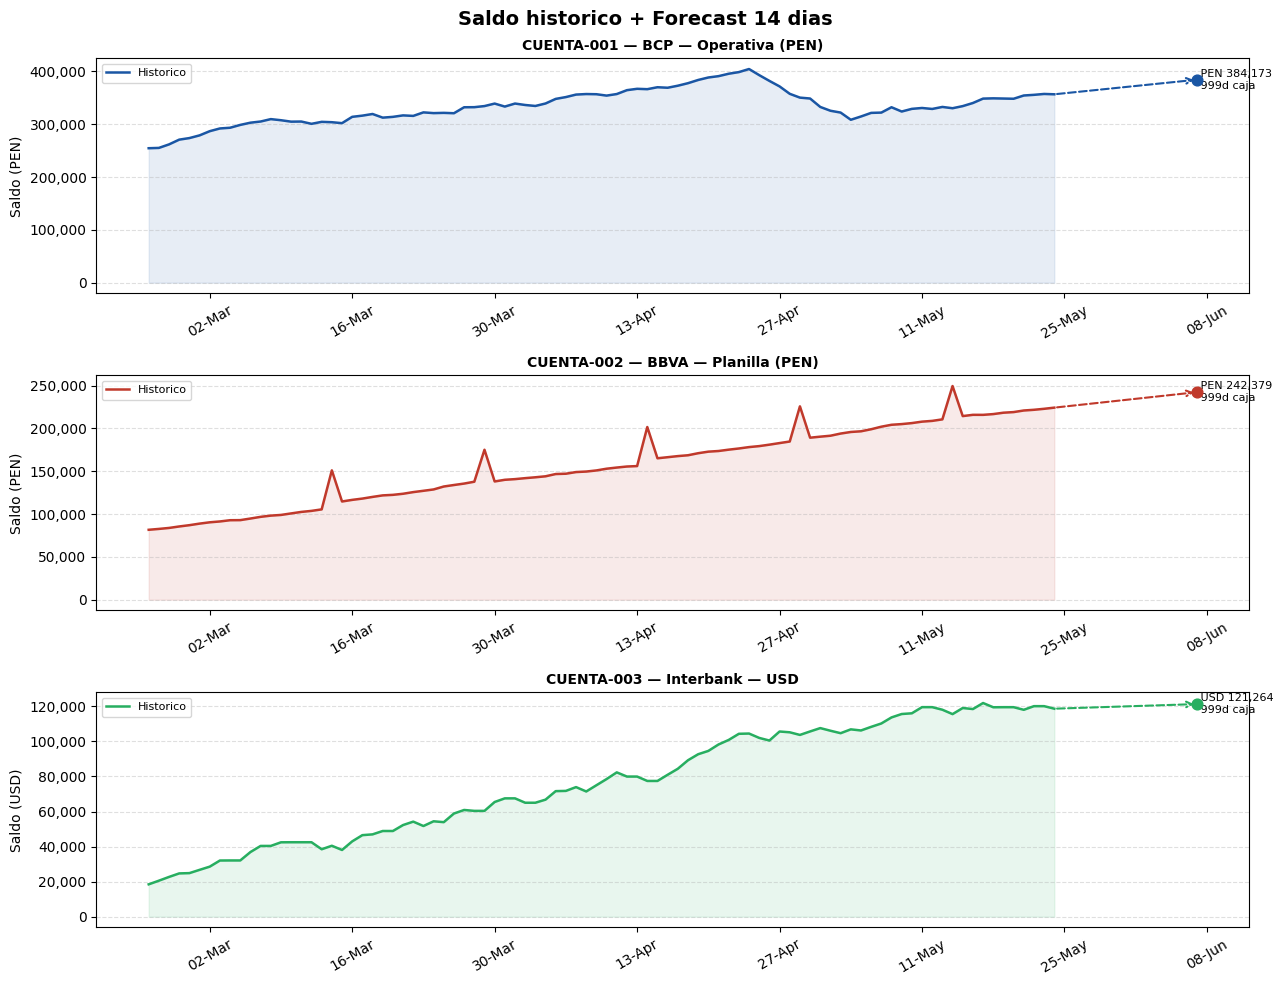

Grafico guardado: data/forecast_14dias.png


In [7]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

df_plot = pd.read_csv(DATA_PATH, parse_dates=['fecha'])

fig, axes = plt.subplots(3, 1, figsize=(13, 10), sharex=False)
fig.suptitle('Saldo historico + Forecast 14 dias', fontsize=14, fontweight='bold')

colores = {'CUENTA-001': '#1a56a4', 'CUENTA-002': '#c0392b', 'CUENTA-003': '#27ae60'}
titulos = {
    'CUENTA-001': 'BCP — Operativa (PEN)',
    'CUENTA-002': 'BBVA — Planilla (PEN)',
    'CUENTA-003': 'Interbank — USD',
}

for ax, cuenta in zip(axes, ['CUENTA-001', 'CUENTA-002', 'CUENTA-003']):
    sub = df_plot[df_plot['cuenta_id'] == cuenta].copy()
    color = colores[cuenta]
    r = resultados[cuenta]
    moneda = r['moneda']

    # Historico
    ax.plot(sub['fecha'], sub['saldo_cierre'], color=color, linewidth=1.8, label='Historico')
    ax.fill_between(sub['fecha'], sub['saldo_cierre'], alpha=0.10, color=color)

    # Forecast: linea desde el ultimo punto
    ultima_fecha = sub['fecha'].max()
    fecha_forecast = ultima_fecha + pd.Timedelta(days=14)
    ax.annotate('', 
        xy=(fecha_forecast, r['forecast_saldo']),
        xytext=(ultima_fecha, r['saldo_actual']),
        arrowprops=dict(arrowstyle='->', color=color, lw=1.5, linestyle='dashed')
    )
    ax.scatter([fecha_forecast], [r['forecast_saldo']], color=color, zorder=5, s=60)
    ax.text(fecha_forecast, r['forecast_saldo'],
        f" {moneda} {r['forecast_saldo']:,.0f}\n {r['dias_de_caja']}d caja",
        fontsize=8, va='center')

    ax.set_title(f"{cuenta} — {titulos[cuenta]}", fontsize=10, fontweight='bold')
    ax.set_ylabel(f'Saldo ({moneda})')
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:,.0f}'))
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%d-%b'))
    ax.xaxis.set_major_locator(mdates.WeekdayLocator(byweekday=0, interval=2))
    ax.tick_params(axis='x', rotation=30)
    ax.grid(axis='y', linestyle='--', alpha=0.4)
    ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig('../data/forecast_14dias.png', dpi=120, bbox_inches='tight')
plt.show()
print('Grafico guardado: data/forecast_14dias.png')

---
## Resumen NB 02

| Artefacto | Ruta | Estado |
|---|---|---|
| Script forecast individual | `.claude/skills/forecast-cashflow/rolling_mean_cashflow.py` | OK |
| Script batch todas las cuentas | `.claude/skills/forecast-cashflow/batch_dias_de_caja.py` | OK |
| SKILL.md del forecast | `.claude/skills/forecast-cashflow/SKILL.md` | OK |
| Grafico forecast 14d | `data/forecast_14dias.png` | OK |

**Siguiente:** `03_skills_tesoreria.ipynb`  
Crearemos los otros 2 SKILLs: `alerta-tesoreria` y `reporte-semanal`.  
El output del forecast (dias_de_caja, confidence, flags) es el INPUT del skill de alertas.